# 🤖 Model Training, Evaluation & Simulation
---
## Overview
This notebook is the **third and final stage** of the stock valuation project.  
It covers the complete machine learning pipeline, from training four separate classification models through to a full investment simulation using historical data.

---
## Notebook Structure

| Stage | What Happens |
|---|---|
| **Data Preparation** | Load the balanced CSV, split by ticker (no leakage), scale features |
| **Model Training** | Train 4 models using GridSearchCV with GroupKFold cross-validation |
| **Evaluation** | Confusion matrices, accuracy scores, classification reports |
| **Feature Importance** | Random Forest feature ranking |
| **SHAP Analysis** | Explainable AI — understand *why* the model makes each prediction |
| **Live Validation** | Test models against real-time stock data from Yahoo Finance |
| **Backtesting** | Simulate model performance on unseen historical periods (2022–2024) |
| **Investment Simulation** | Compare model-driven portfolio returns against the S&P 500 benchmark |

---
## Models Trained

| Model | Type | Key Strength |
|---|---|---|
| **Random Forest** | Ensemble of Decision Trees | Robust, interpretable, handles feature interactions well |
| **XGBoost** | Gradient Boosted Trees | Typically the best performer on tabular financial data |
| **MLP Neural Net** | Feedforward Neural Network | Can capture complex non-linear patterns |
| **KNN** | Instance-based (K-Nearest Neighbours) | Simple baseline; measures similarity in feature space |

---
## Key Design Decision: No Data Leakage
The most important design choice in this notebook is the **ticker-based train/test split**.  
Instead of splitting randomly (which would put the same stock's rows in both train and test), we ensure that **each ticker appears in either training OR testing — never both**.

This prevents the model from "memorising" a specific stock's personality and then being tested on the same stock — which would inflate accuracy but not reflect real-world performance.

## 1. Library Imports

In [1]:
import matplotlib.pyplot as plt                            # Plotting
import matplotlib.ticker as mtick                          # Axis formatting (%, £)
import yfinance as yf                                      # Live stock data
import pandas as pd                                        # DataFrames
import numpy as np                                         # Numerical operations
import time                                               # Rate-limiting API calls
import os                                                  # File existence checks
import seaborn as sns                                      # Statistical visualisation
import simfin as sf                                        # Historical financial data
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold  # Model selection tools
from sklearn.preprocessing import StandardScaler           # Feature scaling for ANN/KNN
from sklearn.ensemble import RandomForestClassifier        # Random Forest model
from xgboost import XGBClassifier                         # XGBoost model
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # Evaluation metrics
from sklearn.neighbors import KNeighborsClassifier         # KNN model
from sklearn.neural_network import MLPClassifier           # Multi-Layer Perceptron (ANN)
import joblib                                              # Save/load model files

## 2. Data Loading & Train/Test Split

### Loading & Encoding the Data
We load the balanced CSV from the collection notebook and apply **one-hot encoding** to the `Sector` column.  
One-hot encoding converts a categorical column (e.g., "Technology", "Healthcare") into several binary (0/1) columns —  
one per sector. This is required because ML models expect numeric inputs only.

### Ticker-Based Split — Preventing Data Leakage
**Problem with a random split:**  
A stock like AAPL has hundreds of rows in the dataset (one per trading day).  
If we split randomly, AAPL rows would appear in *both* training and testing sets.  
The model would learn AAPL's specific patterns during training and "recognise" them during testing — artificially inflating accuracy.

**Our solution — split by ticker:**
1. Get the unique list of all tickers
2. Randomly shuffle them
3. Put 70% of tickers in the training set, 30% in the test set
4. A ticker's rows are 100% in one set only

### GroupKFold for Cross-Validation
Even within the training set, we use `GroupKFold(n_splits=5)` for hyperparameter tuning.  
This ensures that the same ticker never appears in both the fold's training and validation set — maintaining the no-leakage guarantee throughout the entire process.

### Feature Scaling
Tree-based models (RF, XGBoost) are **scale-invariant** — they don't care if PE_Ratio is 0–100 and Volatility is 0–1.  
But **KNN and ANN are scale-sensitive** — a feature with large values would dominate the distance/gradient calculations.  
`StandardScaler` transforms each feature to have mean=0 and std=1, making all features equally weighted.

In [2]:

df = pd.read_csv('balanced_stock_data.csv')
df = pd.get_dummies(df, columns=['Sector'])
# NEW: split by TICKER -> a ticker is in train OR test, never both
all_tickers  = df['Ticker'].unique()
rng          = np.random.default_rng(42)
rng.shuffle(all_tickers)
split_point  = int(len(all_tickers) * 0.70)  # 70/30 split by ticker
train_tickers = all_tickers[:split_point]
test_tickers  = all_tickers[split_point:]

train_mask = df['Ticker'].isin(train_tickers)
test_mask  = df['Ticker'].isin(test_tickers)

X = df.drop(['Target', 'Ticker', 'Timestamp'], axis=1, errors='ignore')
y = df['Target']
groups = df['Ticker']  # kept for GroupKFold in GridSearch

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train    = groups[train_mask]

# Scale Data (Required for ANN and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train tickers: {len(train_tickers)} | Test tickers: {len(test_tickers)}")
print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Training on {len(X.columns)} features: {X.columns.tolist()}")
print(f"\nTest set class balance:\n{y_test.value_counts().sort_index()}")

Train tickers: 104 | Test tickers: 45
Train rows: 1434 | Test rows: 561
Training on 21 features: ['PE_Ratio', 'ROE', 'ROA', 'EPS', 'Dividend_Yield', 'Debt_to_Equity', 'Price_to_Book', 'Price_to_Sales', 'Revenue_Growth', 'Operating_Margin', 'Momentum', 'Volatility', 'sp500_close', 'Sector_Discretionary', 'Sector_Energy', 'Sector_Financials', 'Sector_Healthcare', 'Sector_Industrials', 'Sector_Staples', 'Sector_Technology', 'Sector_Utilities']

Test set class balance:
Target
0    140
1    217
2    204
Name: count, dtype: int64


## 3. Model Training — Random Forest

### What is a Random Forest?
A Random Forest is an ensemble of hundreds of individual decision trees. Each tree:
1. Is trained on a **random subset** of the training data (bootstrapping)
2. At each split, only considers a **random subset** of features

The final prediction is made by **majority vote** across all trees.  
This randomness makes Random Forest very robust to overfitting compared to a single deep tree.

### Hyperparameters Being Tuned

| Parameter | Values Tested | Meaning |
|---|---|---|
| `n_estimators` | 100, 300 | Number of trees — more trees = more stable but slower |
| `max_depth` | 5, 10, 15 | Maximum depth of each tree — deeper = more complex patterns but higher overfitting risk |

### `class_weight='balanced'`
Even though our dataset is balanced overall, this parameter tells the model to pay extra attention to whichever class appears less often in any given training fold. It's an extra safety net against class imbalance.

### GridSearchCV
`GridSearchCV` tries **every combination** of the above hyperparameters and picks the combination that gives the best cross-validation score.  
With `GroupKFold(n_splits=5)`, it runs 5 folds × 6 combinations = 30 training runs total.

In [3]:

param_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 15]   # removed 50 — way too deep for 1311 rows
}
group_cv = GroupKFold(n_splits=5)
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_rf  = GridSearchCV(rf_model, param_rf, cv=group_cv, n_jobs=-1)
grid_rf.fit(X_train, y_train, groups=groups_train)
y_pred_rf = grid_rf.predict(X_test)

print(f"Best Params: {grid_rf.best_params_}")
print(classification_report(y_test, y_pred_rf))

Best Params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       140
           1       0.80      0.74      0.77       217
           2       0.79      0.86      0.82       204

    accuracy                           0.83       561
   macro avg       0.84      0.84      0.84       561
weighted avg       0.83      0.83      0.82       561



## 4. Model Training — XGBoost

### What is XGBoost?
XGBoost (Extreme Gradient Boosting) builds trees **sequentially**. Each new tree corrects the errors made by the previous tree.  
This "boosting" process makes XGBoost extremely powerful on structured/tabular data — it is often the top-performing model in Kaggle competitions involving financial data.

### Key Hyperparameters

| Parameter | Values | Meaning |
|---|---|---|
| `learning_rate` | 0.01, 0.05, 0.1 | How much each tree corrects the previous — lower = more careful but needs more trees |
| `n_estimators` | 100, 200 | Number of sequential trees |
| `max_depth` | 3, 4 | Shallow trees prevent overfitting — generally 3–6 is recommended for financial data |
| `subsample` | 0.8 | Each tree is trained on 80% of the data — adds randomness, reduces overfitting |
| `colsample_bytree` | 0.6 | Each tree only uses 60% of features — prevents any single feature from dominating |

### `reg_lambda=1` (L2 Regularisation)
This penalises large leaf values in the trees — a form of regularisation that helps the model generalise to unseen data rather than memorising training patterns.

### `eval_metric='mlogloss'`
For multi-class classification (3 classes), `mlogloss` (multi-class log loss) is the appropriate evaluation metric during training.

In [4]:
param_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'subsample': [0.8],
    'colsample_bytree': [0.6]
}

xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    reg_lambda=1
)
# Use GroupKFold so the same ticker never leaks across CV folds
group_cv  = GroupKFold(n_splits=5)
grid_xgb  = GridSearchCV(xgb_model, param_xgb, cv=group_cv, n_jobs=-1)
grid_xgb.fit(X_train, y_train, groups=groups_train)
y_pred_xgb = grid_xgb.predict(X_test)

print(f"Best Params: {grid_xgb.best_params_}")
print(classification_report(y_test, y_pred_xgb))

Best Params: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       140
           1       0.80      0.76      0.78       217
           2       0.84      0.87      0.86       204

    accuracy                           0.83       561
   macro avg       0.84      0.84      0.84       561
weighted avg       0.83      0.83      0.83       561



## 5. Model Training — MLP Neural Network (ANN)

### What is an MLP?
A Multi-Layer Perceptron (MLP) is a feedforward neural network.  
Input features flow through one or more **hidden layers** (where non-linear transformations occur) before producing a final class prediction.

### Why Does Scaling Matter Here?
Neural networks use **gradient descent** to learn weights. If one feature has values 0–1000 and another 0–0.01, the gradients will be vastly different in magnitude, causing the network to train poorly or diverge.  
`X_train_scaled` and `X_test_scaled` (from `StandardScaler`) ensure all inputs are on the same scale.

### Hyperparameters Tuned

| Parameter | Values | Meaning |
|---|---|---|
| `hidden_layer_sizes` | (64, 32) or (100,) | Architecture — `(64, 32)` = 2 hidden layers with 64 then 32 neurons; `(100,)` = 1 hidden layer with 100 neurons |
| `alpha` | 0.0001, 0.05 | L2 regularisation strength — higher alpha = more regularisation, reduces overfitting |

`max_iter=1000` ensures the network has enough training iterations to converge.

In [5]:
param_ann = {
    'hidden_layer_sizes': [(64, 32), (100,)],
    'alpha': [0.0001, 0.05]
}
group_cv  = GroupKFold(n_splits=5)
grid_ann  = GridSearchCV(MLPClassifier(max_iter=1000, random_state=42), param_ann, cv=group_cv, n_jobs=-1)
grid_ann.fit(X_train_scaled, y_train, groups=groups_train)
y_pred_ann = grid_ann.predict(X_test_scaled)

print(f"Best Params: {grid_ann.best_params_}")
print(classification_report(y_test, y_pred_ann))

Best Params: {'alpha': 0.05, 'hidden_layer_sizes': (100,)}
              precision    recall  f1-score   support

           0       0.59      0.51      0.55       140
           1       0.53      0.50      0.51       217
           2       0.67      0.77      0.72       204

    accuracy                           0.60       561
   macro avg       0.60      0.59      0.59       561
weighted avg       0.60      0.60      0.60       561



## 6. Model Training — K-Nearest Neighbours (KNN)

### What is KNN?
KNN is a simple, intuitive model: to classify a new stock, it finds the `k` most similar stocks in the training set (using Euclidean distance in feature space) and takes a majority vote.

### Why KNN is a Useful Baseline
KNN makes **no assumptions** about the shape of the data distribution. It simply asks: *"What were stocks with similar PE, ROE, Momentum, etc. classified as?"*  
If KNN performs poorly, it suggests the feature space doesn't have clean, tight clusters — which would be useful information about the data.

### Hyperparameters Tuned

| Parameter | Values | Meaning |
|---|---|---|
| `n_neighbors` | 3, 7, 15 | How many neighbours to consult — lower k = noisier but more flexible; higher k = smoother but may miss local patterns |
| `weights` | 'uniform', 'distance' | `uniform` = all neighbours vote equally; `distance` = closer neighbours have more influence |

> ⚠️ KNN uses `X_train_scaled` / `X_test_scaled` because distance calculations are scale-sensitive.

In [6]:
param_knn = {
    'n_neighbors': [3, 7, 15],
    'weights': ['uniform', 'distance']
}
group_cv  = GroupKFold(n_splits=5)
grid_knn  = GridSearchCV(KNeighborsClassifier(), param_knn, cv=group_cv, n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train, groups=groups_train)
y_pred_knn = grid_knn.predict(X_test_scaled)

print(f"Best Params: {grid_knn.best_params_}")
print(classification_report(y_test, y_pred_knn))

Best Params: {'n_neighbors': 7, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.48      0.61      0.54       140
           1       0.52      0.42      0.46       217
           2       0.57      0.59      0.58       204

    accuracy                           0.53       561
   macro avg       0.52      0.54      0.53       561
weighted avg       0.53      0.53      0.52       561



## 7. Feature Importance & Random Forest Backtest Results

### Feature Importance (Random Forest)
Random Forest can tell us exactly **how much each feature contributed** to its classification decisions across all 300 trees.

**Importance Score** = Average reduction in "impurity" (how mixed the classes are) that a feature caused when it was used as a split point, averaged over all trees.

- **Higher score** = Feature is used more often AND reduces class confusion more effectively
- **Lower score** = Feature contributes little to separating the classes

> 💡 This ranking is valuable for feature selection and for explaining to stakeholders which financial signals the model trusts most.

### Confusion Matrix
The confusion matrix shows where the model agrees and disagrees with the Graham Formula labels.

- **Diagonal (top-left to bottom-right)**: Correct predictions
- **Off-diagonal**: Misclassifications — e.g., the model predicted "Overvalued" but the Graham label said "Fair"

Understanding *which* class gets confused with *which* other class tells us about the model's systematic biases.


--- Feature Ranking for your Model ---
                 Feature  Importance
0               PE_Ratio    0.209250
6          Price_to_Book    0.168075
1                    ROE    0.073985
2                    ROA    0.066170
12           sp500_close    0.065824
7         Price_to_Sales    0.060484
10              Momentum    0.059669
9       Operating_Margin    0.057967
5         Debt_to_Equity    0.056206
11            Volatility    0.040873
3                    EPS    0.036710
4         Dividend_Yield    0.034850
8         Revenue_Growth    0.033556
14         Sector_Energy    0.012772
20      Sector_Utilities    0.005281
17    Sector_Industrials    0.004205
15     Sector_Financials    0.003624
18        Sector_Staples    0.003093
16     Sector_Healthcare    0.002822
19     Sector_Technology    0.002497
13  Sector_Discretionary    0.002084
--- MODEL BACKTEST RESULTS ---
Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Overall Accuracy: 82.53%

Detailed Classification Report:
 

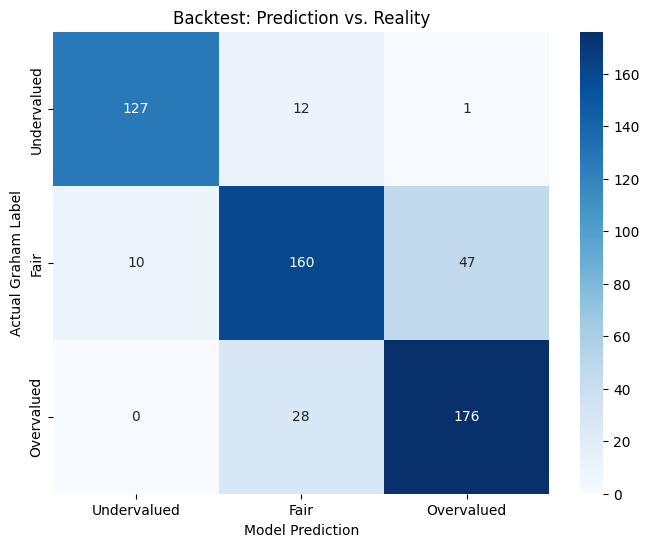

In [7]:
# 1. Evaluate the Best Model found by GridSearch
best_rf = grid_rf.best_estimator_
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame to view them clearly
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Feature Ranking for your Model ---")
print(importance_df)
y_pred_rf = best_rf.predict(X_test)

# 2. Simple Performance Printout
print("--- MODEL BACKTEST RESULTS ---")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 3. Simple Visual: Confusion Matrix
# This shows exactly where the model "disagrees" with the Graham Formula
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Undervalued', 'Fair', 'Overvalued'],
            yticklabels=['Undervalued', 'Fair', 'Overvalued'])
plt.xlabel('Model Prediction')
plt.ylabel('Actual Graham Label')
plt.title('Backtest: Prediction vs. Reality')
plt.show()

## 8. Live Prediction Function — `fetch_stock_features()`

### Purpose
This function is the **inference pipeline** — it takes a ticker symbol and returns a DataFrame of features that can be fed directly into a trained model for real-time prediction.

It mirrors the feature engineering from `fetchStockInfo()` in the data collection notebook, but uses **live data from Yahoo Finance** rather than the cached SimFin data.

### Steps Inside the Function

| Step | What Happens |
|---|---|
| 1. Price History | Download 5 years of daily OHLCV data from Yahoo Finance |
| 2. Current Price | Extract the most recent closing price |
| 3. Sector Mapping | Map Yahoo Finance sector to internal label |
| 4. EPS | Trailing EPS (12 months) or Forward EPS as fallback |
| 5. Book Value | Net asset value per share |
| 6. PE Ratio | Trailing P/E or computed from price/EPS |
| 7. Debt-to-Equity | Careful handling for Financial sector (banks have structurally high D/E) |
| 8. ROE | Return on equity (with fallback computation) |
| 9. Other Ratios | ROA, Revenue Growth, Operating Margin, P/B, P/S |
| 10. Graham Value | Computed from EPS and Book Value |
| 11. Feature Engineering | Momentum, Volatility, S&P 500 close |
| 12. One-Hot Encoding | Sector column encoded as binary columns |
| 13. NaN Handling | Forward-fill then fill remaining NaNs with 0 |

### Why the First 90 Rows Are Dropped
`Momentum` uses a 90-day rolling average.  
The first 90 rows have incomplete rolling windows (NaN values).  
We drop these to ensure every remaining row has fully valid features.

In [8]:

def fetch_stock_features(ticker):
    """
    Fetches live data, engineers features, one-hot encodes the sector,
    and aligns the row to the exact schema the model was trained on.

    Args:
        ticker        (str):  stock ticker e.g. "AAPL"
        model_columns (list): column names from model_columns.pkl

    Returns:
        aligned       (pd.DataFrame) - single row ready for model.predict()
        graham_value  (float)        - Graham Intrinsic Value
        current_price (float)        - latest closing price

    Raises:
        ValueError with a clear message if any critical field is missing.
    """
    import yfinance as yf

    ticker = ticker.upper().strip()

    # ── 1. Price history ──────────────────────────────────────────────────────
    ticker_obj = yf.Ticker(ticker)
    history    = ticker_obj.history(period="5y")

    if history.empty:
        raise ValueError(
            f"No price history found for '{ticker}'. "
            "Check the ticker symbol is correct."
        )

    time.sleep(0.5)
    info = ticker_obj.info

    current_price = float(history["Close"].iloc[-1])

    sp500 = yf.Ticker("^GSPC").history(period="5y")["Close"]
    # ── 3. Sector — map to training label ─────────────────────────────────────
    raw_sector = info.get("sector")
    if not raw_sector:
        raise ValueError(
            f"Sector not available for '{ticker}'. "
            "ETFs, indices, and crypto are not supported."
        )

    sector = SECTOR_MAP.get(raw_sector)
    if not sector:
        raise ValueError(
            f"Unrecognised sector '{raw_sector}' for '{ticker}'. "
            f"Supported sectors: {list(SECTOR_MAP.keys())}"
        )

    # ── 4. EPS ────────────────────────────────────────────────────────────────
    eps = info.get("trailingEps") or info.get("forwardEps")
    if eps is None:
        raise ValueError(f"EPS not available for '{ticker}'.")

    # ── 5. Book Value ─────────────────────────────────────────────────────────
    book_value = info.get("bookValue")
    if book_value is None :
        raise ValueError(f"Book value not available for '{ticker}'.")

    # ── 6. P/E Ratio ──────────────────────────────────────────────────────────
    pe_ratio = info.get("trailingPE")
    if pe_ratio is None:
        if eps and eps != 0:
            pe_ratio = current_price / eps
        else:
            raise ValueError(f"P/E ratio cannot be computed for '{ticker}'.")

    # ── 7. Debt to Equity ─────────────────────────────────────────────────────
    de_raw = info.get("debtToEquity")
    if not de_raw or de_raw == 0:
        if sector == "Financials":
            debt_to_equity = info.get("priceToBook", 0) or 0
        else:
            total_debt = info.get("totalDebt")
            shares_outstanding = info.get("sharesOutstanding")
            if total_debt and shares_outstanding and book_value != 0:
                total_equity = shares_outstanding * book_value
                debt_to_equity = total_debt / total_equity
            else:
                raise ValueError(f"Debt-to-equity cannot be computed for '{ticker}'.")
    else:
        debt_to_equity = de_raw / 100   # yfinance returns as percentage
    roe = info.get("returnOnEquity")
    if roe is None:
        net_income = info.get("netIncomeToCommon")
        shares_outstanding = info.get("sharesOutstanding")
        if net_income and shares_outstanding and book_value != 0:
            roe = net_income / (shares_outstanding * book_value)
        else:
            raise ValueError(f"ROE cannot be computed for '{ticker}'.")
    # ── 8. Remaining fundamentals ─────────────────────────────────────────────
    dividend_yield   = info.get("dividendYield") or 0.0  # 0 is valid (e.g. TSLA)
    roa              = info.get("returnOnAssets")
    revenue_growth   = info.get("revenueGrowth")
    operating_margin = info.get("operatingMargins")
    price_to_book    = info.get("priceToBook")
    price_to_sales   = info.get("priceToSalesTrailing12Months")

    missing = []
    if roe              is None: missing.append("ROE")
    if roa              is None: missing.append("ROA")
    if revenue_growth   is None: missing.append("Revenue Growth")
    if operating_margin is None: missing.append("Operating Margin")
    if price_to_book    is None: missing.append("Price to Book")
    if price_to_sales   is None: missing.append("Price to Sales")

    if missing:
        raise ValueError(f"Missing fields for '{ticker}': {', '.join(missing)}.")

    # ── 9. Graham Intrinsic Value ─────────────────────────────────────────────
    if eps is not None and book_value is not None and (eps * book_value) != 0:
        graham_value = float(np.sqrt(22.5 * abs(eps * book_value)))
    else:
        graham_value = 0.0

    # ── 10. Build feature DataFrame ───────────────────────────────────────────
    df = history.copy()

    df["PE_Ratio"]         = pe_ratio
    df["ROE"]              = roe
    df["ROA"]              = roa
    df["EPS"]              = eps
    df["Dividend_Yield"]   = dividend_yield
    df["Debt_to_Equity"]   = debt_to_equity
    df["Price_to_Book"]    = price_to_book
    df["Price_to_Sales"]   = price_to_sales
    df["Revenue_Growth"]   = revenue_growth
    df["Operating_Margin"] = operating_margin
    df["Momentum"]         = df["Close"].rolling(30).mean() / df["Close"].rolling(90).mean()
    df["Volatility"]       = df["Close"].pct_change().rolling(30).std()
    df["sp500_close"]      = sp500

    # ── 11. Sector one-hot encoding ───────────────────────────────────────────
    # Mirrors pd.get_dummies(df, columns=['Sector']) from training
    sector_col     = f"Sector_{sector}"
    df[sector_col] = 1

    # ── 12. Select feature columns ────────────────────────────────────────────
    feature_cols = [
        "PE_Ratio", "ROE", "ROA", "EPS", "Dividend_Yield",
        "Debt_to_Equity", "Price_to_Book", "Price_to_Sales",
        "Revenue_Growth", "Operating_Margin",
        "Momentum", "Volatility","sp500_close",
        sector_col
    ]

    df = df[feature_cols]

    # ── 13. NaN handling — mirrors training notebook ──────────────────────────
    df = df.ffill()    # carry last known value forward
    df = df.fillna(0)  # any remaining NaNs at start of rolling window → 0
    df = df.iloc[90:]  # drop first 90 rows before rolling indicators are vali


    return  df, graham_value

## 9. Live Validation — Testing Against Real Stocks

### Purpose
This section applies the trained XGBoost model to a diverse set of **real stocks in real time** using live data from Yahoo Finance.

### What Happens For Each Ticker
1. Fetch the current price and basic info
2. Call `fetch_stock_features()` to engineer the live feature row
3. Pass the feature row into the XGBoost model → get an AI prediction (0/1/2)
4. Independently compute the Graham Formula label based on current price vs Graham Value
5. Compare the two: **does the AI agree with the Graham Formula?**

### What "DISRUPTION DETECTED" Means
When the AI label ≠ Graham Formula label, we flag it as a **disruption**.  
This is actually the most interesting case — it means the AI has found a stock where:
- The Graham math says one thing (e.g., "Overvalued")
- But the ML model, having learned from 5 years of diverse stocks, says another (e.g., "Fair")

These disagreements are worth investigating. The model may have detected a quality premium (high ROE, strong momentum) that Graham's simple formula doesn't capture.

### The Diverse Test Universe
The tickers span Technology, Financials, Healthcare, Energy, Staples, Industrials, and Beaten-Down stocks — deliberately covering a wide range of fundamental profiles to stress-test the model.

In [9]:
SECTOR_MAP = {
    'Technology':             'Technology',
    'Financial Services':     'Financials',
    'Healthcare':             'Healthcare',
    'Consumer Cyclical':      'Discretionary',
    'Consumer Defensive':     'Staples',
    'Energy':                 'Energy',
    'Industrials':            'Industrials',
    'Utilities':              'Utilities',
    'Real Estate':            'Utilities',
    'Communication Services': 'Technology',
    'Basic Materials':        'Industrials',
}
test_tickers = [
    # --- THE TECH GIANTS (High PE, High Growth) ---
    "NVDA", # Nvidia: Extreme growth vs low book value.
    "MSFT", # Microsoft: Massive quality premiums.
    "AAPL",# Apple: High ROE, but expensive by Graham math.
    "TSLA",
    "SNOW",
    "CAT",
    "JNJ",
    
    
    # --- THE SPECULATIVE & VOLATILE ---
    "COIN", # Coinbase: High volatility, fluctuates wildy from Graham's anchor.
    "PLTR", # Palantir: Data/AI growth play with non-traditional financials.
    
    # --- THE VALUE TRAPS / DEBT HEAVY ---
    "T",    # AT&T: High debt, low growth. Will AI call it overvalued despite low price?
    "F",    # Ford: Classic industrial. Does AI agree with the low Graham valuation?
    "BA",   # Boeing: High debt and operational issues.
    
    # --- THE CONSISTENT QUALITY (AI should love these) ---
    "COST", # Costco: High PE usually, but incredible efficiency/ROE.
    "V",    # Visa: Asset-light, ultra-high margins.
    "PG",   # Procter & Gamble: Defensive, steady metrics.
    
    # --- THE RECOVERY / TRANSITION PLAYS ---
    "DIS",  # Disney: Moving from legacy to streaming growth.
    "INTC", # Intel: Struggling legacy tech. A test of "Momentum" vs "Value."
    
    # --- THE "STRICT VALUE" PLAYS ---
    "BRK-B",# Berkshire Hathaway: The king of value.
    "JPM" , "XOM", "CVX", "COP", "OXY", "DVN", "MRO", "HAL", "SLB", "PSX", "VLO",
    "MPC", "HES", "EOG", "PXD", "BP", "SHEL", "TTE", "E", "EC", "YPF",

    # --- FINANCIALS (low P/B, decent ROE, your Graham formula works here) ---
    "JPM", "BAC", "WFC", "C", "USB", "PNC", "TFC", "CFG", "KEY", "HBAN",
    "RF", "FITB", "MTB", "ZION", "FHN", "BEN", "IVZ", "GS", "MS", "MET",

    # --- INDUSTRIALS (steady earnings, real assets) ---
    "GE", "HON", "MMM", "CAT", "DE", "EMR", "ETN", "PH", "ITW", "DOV",
    "ROK", "IR", "CARR", "TXT", "LMT", "NOC", "RTX", "GD", "HII", "BWA",

    # --- HEALTHCARE / PHARMA (strong EPS, beaten down valuations) ---
    "JNJ", "PFE", "MRK", "ABBV", "BMY", "GILD", "CVS", "CI", "HUM", "CNC",
    "MOH", "AMGN", "BIIB", "VTRS", "OGN", "JAZZ", "PBH", "PRGO", "ENR", "BCO",

    # --- STAPLES (consistent EPS, dividends, model likes dividend yield) ---
    "KO", "PEP", "KHC", "MO", "BTI", "GIS", "K", "CPB", "CAG", "SJM",
    "HRL", "TSN", "PG", "CL", "CHD", "SPB", "CENT", "COTY", "KR", "SFM",

    # --- BEATEN DOWN / LOW P/E ---
    "INTC", "BA", "T", "VZ", "DIS", "WBD", "PARA", "F", "GM", "STLA",  # JPMorgan: Financial sector test for the Graham Formula.
]
print("\n--- FINAL AI VALIDATION (Clean & Bulletproof) ---")

for ticker in test_tickers:
    try:
        # 1. Fetch RAW data for Graham Math and Price
        t = yf.Ticker(ticker)
        info = t.info
        # Get just the very last price point
        hist = t.history(period="1d")
        if hist.empty: continue
        current_price = hist['Close'].iloc[-1]
        
        # 2. Get AI Features and Graham Value from your function
        # (df_live contains only the columns the AI needs)
        pe_ratio = info.get('trailingPE', 0)
        df_live, g_val = fetch_stock_features(ticker)
        if df_live.empty: continue
        
        # 3. Create Template Row (Must match X_train columns exactly)
        input_row = pd.DataFrame(0.0, index=[0], columns=X.columns)
        
        # 4. Fill Features (using the most recent row from fetchStockInfo)
        latest_data = df_live.iloc[-1]
        for col in X.columns:
            if col in latest_data:
                input_row.loc[0, col] = float(latest_data[col])
            # Handle Sector columns (One-Hot Encoding)
            elif col.startswith('Sector_'):
                sector_name = latest_data.get('Sector', 'Unknown')
                if col == f"Sector_{sector_name}":
                    input_row.loc[0, col] = 1.0

        # 5. Scale and Predict
       
        ai_idx = grid_xgb.predict(input_row)[0]
        
        # 6. Graham Label Logic
        if current_price < (g_val * 0.9): formula_idx = 0
        elif current_price > (g_val * 1.1): formula_idx = 2
        else: formula_idx = 1
        
        # Mapping
        labels = {0: "Undervalued", 1: "Fair", 2: "Overvalued"}
        
        print(f"STOCK: {ticker: <5} | Price: {current_price: >7.2f} |  P/E: {pe_ratio: >7.2f} | Graham: {g_val: >7.2f}")
        print(f"  > Graham Says: {labels[formula_idx]}")
        print(f"  > AI Says:     {labels[ai_idx]}")
        
        if formula_idx != ai_idx:
            print("  *** DISRUPTION DETECTED ***")
        print("-" * 45)
            
    except Exception as e:
        print(f"Error testing {ticker}: {e}")


--- FINAL AI VALIDATION (Clean & Bulletproof) ---
STOCK: NVDA  | Price:  202.93 |  P/E:   41.50 | Graham:   26.68
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: MSFT  | Price:  419.70 |  P/E:   26.29 | Graham:  137.46
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: AAPL  | Price:  270.67 |  P/E:   34.26 | Graham:   32.65
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: TSLA  | Price:  377.22 |  P/E:  349.30 | Graham:   23.07
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: SNOW  | Price:  139.82 |  P/E:    0.00 | Graham:   22.30
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: CAT   | Price:  829.52 |  P/E:   44.15 |

$MRO: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


STOCK: HAL   | Price:   39.31 |  P/E:   21.72 | Graham:   22.90
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: SLB   | Price:   54.66 |  P/E:   23.26 | Graham:   30.38
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: PSX   | Price:  160.65 |  P/E:   14.90 | Graham:  132.63
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: VLO   | Price:  233.52 |  P/E:   30.81 | Graham:  116.34
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: MPC   | Price:  220.52 |  P/E:   16.68 | Graham:  132.13
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------


HTTP Error 404: 
$HES: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


STOCK: EOG   | Price:  132.88 |  P/E:   14.57 | Graham:  106.70
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------


...

STOCK: CPB   | Price:   20.98 |  P/E:   11.40 | Graham:   23.59
  > Graham Says: Undervalued
  > AI Says:     Undervalued
---------------------------------------------
STOCK: CAG   | Price:   14.40 |  P/E:    0.00 | Graham:    6.20
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: SJM   | Price:   95.49 |  P/E:    0.00 | Graham:  114.10
  > Graham Says: Undervalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: HRL   | Price:   21.82 |  P/E:   24.52 | Graham:   17.00
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: TSN   | Price:   64.83 |  P/E:  115.78 | Graham:   25.40
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: PG    | Price:  150.71 |  P/E:   22.33 | Graham:   58.45
  > Graham Says: Overvalued
  >

$DIS: possibly delisted; no price data found  (period=5y)


Error testing DIS: No price history found for 'DIS'. Check the ticker symbol is correct.
STOCK: WBD   | Price:   26.99 |  P/E:   93.05 | Graham:    9.72
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------


HTTP Error 404: 
$PARA: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


STOCK: F     | Price:   12.43 |  P/E:    0.00 | Graham:   20.44
  > Graham Says: Undervalued
  > AI Says:     Undervalued
---------------------------------------------
STOCK: GM    | Price:   77.74 |  P/E:   23.77 | Graham:   70.53
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: STLA  | Price:    8.16 |  P/E:    0.00 | Graham:   66.74
  > Graham Says: Undervalued
  > AI Says:     Undervalued
---------------------------------------------


## 10. SHAP — Explainable AI Analysis

### What is SHAP?
SHAP (SHapley Additive exPlanations) is a technique from game theory applied to machine learning.  
It answers the question: *"How much did each feature contribute to this specific prediction?"*

This is critical for financial applications where we need to explain decisions to stakeholders or regulators.

### The Three SHAP Plots

#### Plot 1 — Beeswarm Summary Plot
- Each dot = one stock/row in the test set
- X-axis = SHAP value (positive pushes toward "Overvalued", negative toward "Undervalued")
- Colour = the actual feature value (red = high, blue = low)
- Interpretation: *"What does the model think makes a stock overvalued?"*

#### Plot 2 — Bar Plot (Class 0 — Undervalued)
- Shows average absolute SHAP values for the "Undervalued" class
- Identifies which features the model relies on most heavily to detect undervaluation

#### Plot 3 — Waterfall Plot (Single Stock Explanation)
- Shows the breakdown for a **single specific prediction**
- Each bar shows how much a specific feature pushed the prediction up or down
- The `base_value` (expected value) is the model's average prediction before seeing any features
- Interpreting this for one stock = *"Why did the model say AAPL is Fair Value today?"*

> 💡 SHAP is based on `TreeExplainer` which directly interrogates the decision trees — fast and exact for tree-based models.

<Figure size 1000x600 with 0 Axes>

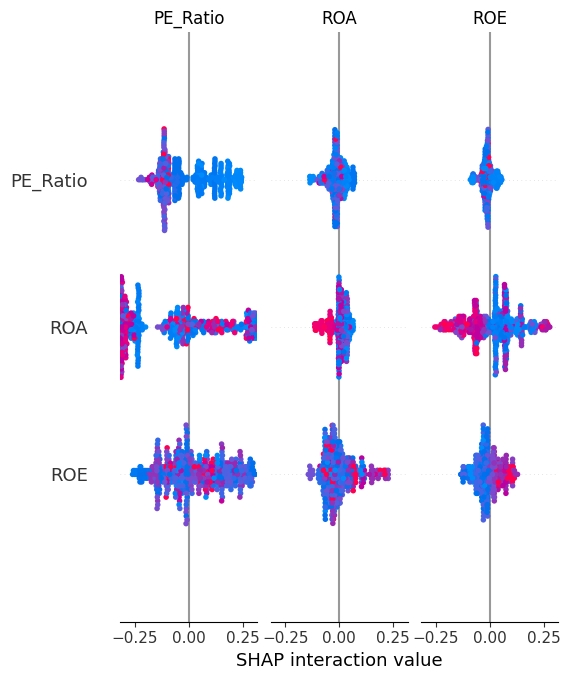

In [13]:
import shap
import matplotlib.pyplot as plt

# 1. Get the best model
rf_best = grid_rf.best_estimator_ 

# 2. Re-initialize explainer
rf_explainer = shap.TreeExplainer(rf_best)
# 2. Initialize the Explainer
# We use 'X_test' as the data to explain
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

# 3. Create the Summary Plot
# This "Beeswarm" plot is the gold standard for AI research
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)

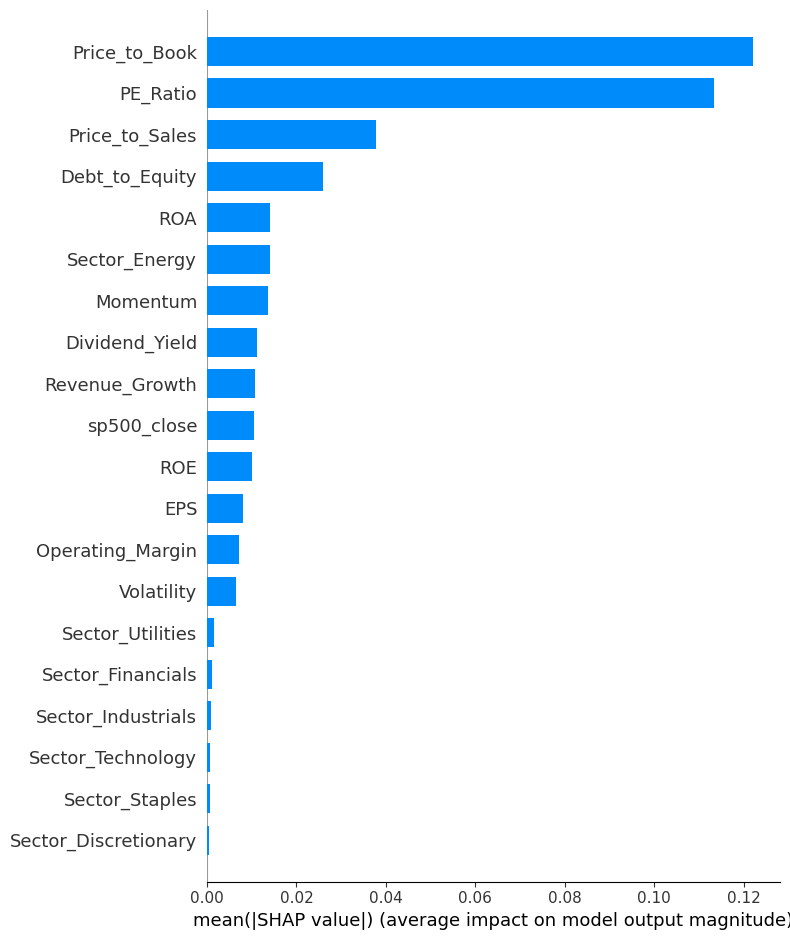

In [11]:
# We wrap it in an Explanation object so SHAP can read it easily
# shap_values[..., 0] or shap_values[0] depending on your XGBoost version
# Let's try the most robust way:
class_0_values = shap_values[..., 0] if len(shap_values.shape) == 3 else shap_values[0]

shap.summary_plot(class_0_values, X_test, plot_type="bar")


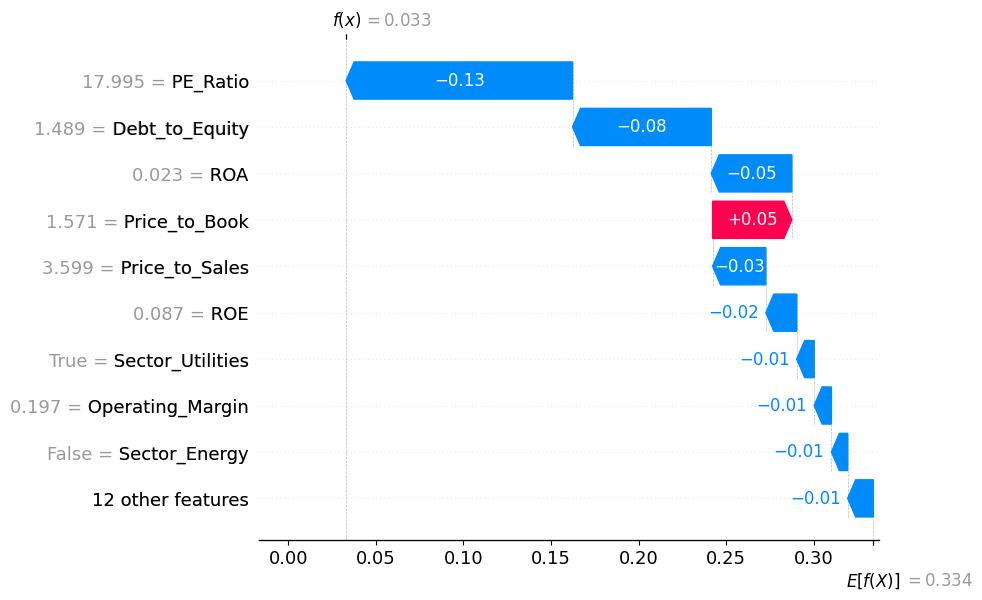

In [12]:
# Explaining the very first stock in your test set
stock_to_explain = 0 
class_to_explain = 0 # 0=Under, 1=Fair, 2=Over

# 3. Create the Explanation object correctly
exp = shap.Explanation(
    values=shap_values[stock_to_explain, :, class_to_explain], 
    base_values=explainer.expected_value[class_to_explain], 
    data=X_test.iloc[stock_to_explain], 
    feature_names=X_test.columns
)

# 4. Plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp)
plt.show()


## 11. Model Comparison — All Four Confusion Matrices
This cell creates a **2×2 grid of confusion matrices** — one for each trained model — for side-by-side comparison.

### Reading Each Matrix
Rows = **Actual** Graham label | Columns = **Model Prediction**  
Numbers on the diagonal = correct predictions  
Numbers off the diagonal = mistakes

### Metrics Displayed
- **Accuracy**: Percentage of all predictions that were correct
- **Macro F1**: Average F1 score across all 3 classes, treating each class equally important

### What to Look For
- Which model has the most errors on the diagonal? (best accuracy)
- Which class (Undervalued / Fair / Overvalued) is hardest to predict correctly for each model?
- Is XGBoost better than Random Forest? Does ANN or KNN underperform significantly?

> The chart is saved as `confusion_matrices_all.png` for your dissertation.

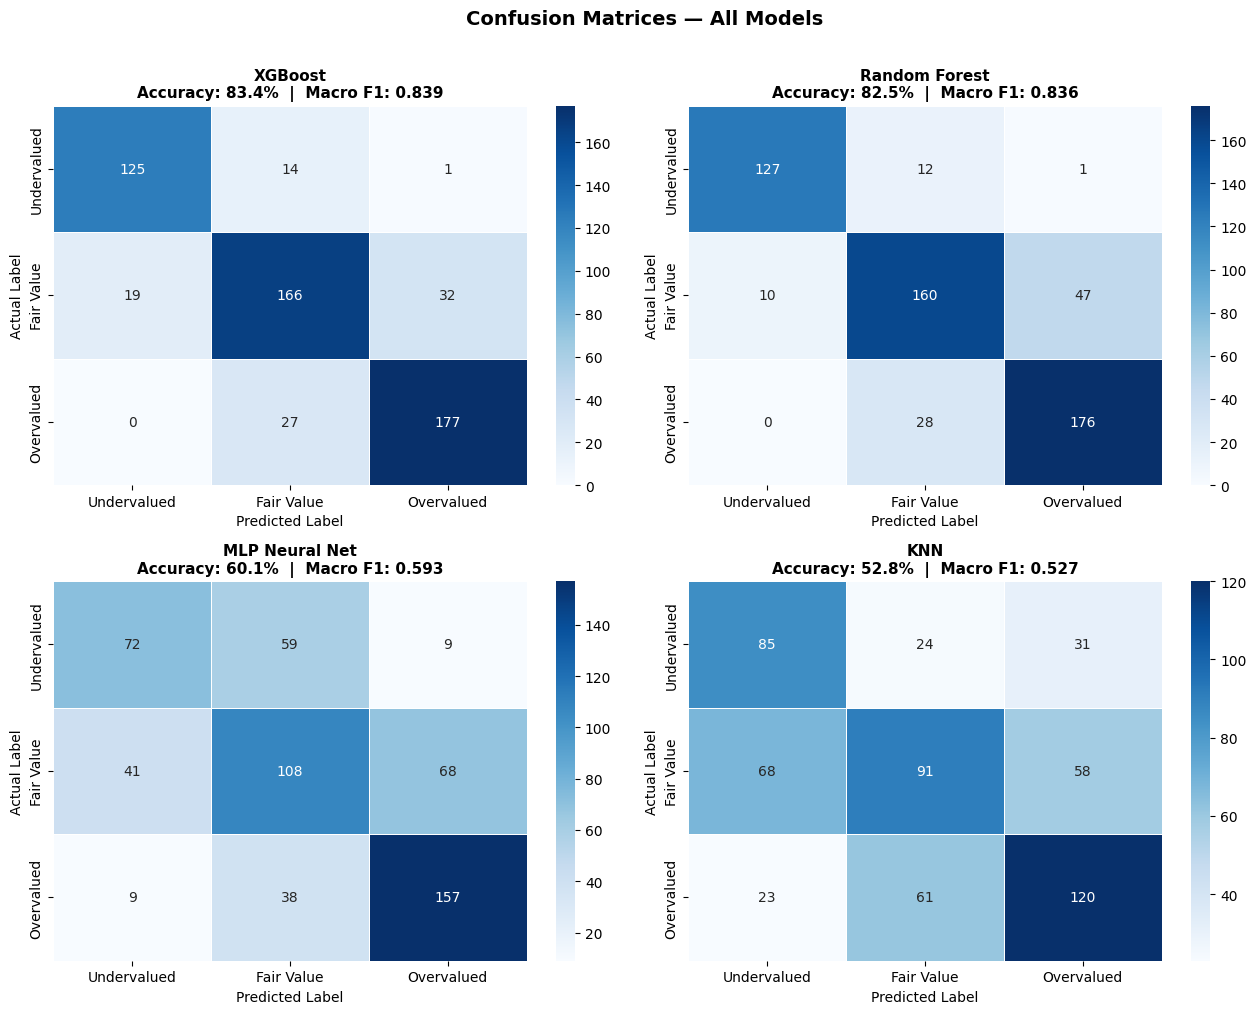

Saved: confusion_matrices_all.png


In [8]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, f1_score
)

CLASS_NAMES = ['Undervalued', 'Fair Value', 'Overvalued']

# ── All 4 models with their test predictions ──────────────────────────────
models = {
    'XGBoost':        y_pred_xgb,
    'Random Forest':  y_pred_rf,
    'MLP Neural Net': y_pred_ann,
    'KNN':            y_pred_knn,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5
    )
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\nAccuracy: {acc:.1%}  |  Macro F1: {f1:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all.png')

## 12. SimFin Reconfiguration
We re-initialise the SimFin API connection here because the backtesting section below requires fresh access to historical financial statements.  
SimFin data is loaded from the local cache (already downloaded earlier), so this is fast.

In [14]:
from dotenv import load_dotenv


load_dotenv()

api_key = os.getenv("SIMFIN_API_KEY")

if not api_key:
    raise ValueError("API key not found")

sf.set_api_key(api_key)
sf.set_data_dir(os.path.expanduser('~/simfin_data/'))

print("SimFin configured")
print('Loading SimFin datasets (first run downloads, then cached)...')
sf_income  = sf.load_income(variant='annual',  market='us')
sf_balance = sf.load_balance(variant='annual', market='us')
print(f'  Income rows:  {len(sf_income)}')
print(f'  Balance rows: {len(sf_balance)}')


SimFin configured
Loading SimFin datasets (first run downloads, then cached)...
Dataset "us-income-annual" on disk (33 days old).

- Extracting zip-file ... Done!
- Loading from disk ... 

C:\Users\TheSa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\simfin\load.py:154: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(path, sep=';', header=0,


Done!
Dataset "us-balance-annual" on disk (33 days old).

- Extracting zip-file ... Done!
- Loading from disk ... 

C:\Users\TheSa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\simfin\load.py:154: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(path, sep=';', header=0,


Done!
  Income rows:  17025
  Balance rows: 17025


## 13. Backtesting Infrastructure — Sliding Window Approach

### What is Backtesting?
Backtesting asks: *"If we had used this model in the past, how well would it have predicted valuations?"*

It is a critical validation step in quantitative finance to ensure the model generalises across different market regimes, not just the specific period it was trained on.

### Sliding Window Design
We define 3 overlapping time windows, each with a dedicated training period and testing period:

| Window Label | Train Period | Test Period | Market Context |
|---|---|---|---|
| 2022 (Rate Rise) | 2020–2021 | 2022 | Interest rate hikes, tech selloff |
| 2023 (AI Rally) | 2021–2022 | 2023 | AI-driven rally, S&P recovery |
| 2024 (Bull Market) | 2022–2023 | 2024 | Continued bull market |

By testing across 3 different market regimes, we get a robust picture of model reliability.

### `build_features_for_window_simfin()` — Point-in-Time Feature Building
This function is similar to `fetchStockInfo()` but designed for historical backtesting windows.

**Key technique — `pd.merge_asof`:**  
This merges price data with the most recent available annual report on or before each trading day.  
It is the correct way to join fundamentals and price history without introducing look-ahead bias.

**6-Month Warmup Period:**  
The function starts fetching price data 6 months before the window start date.  
This ensures Momentum (90-day MA) and Volatility (30-day rolling std) are fully computed from day 1 of the window.

In [15]:


# --- 1. CONFIGURATION ---
BACKTEST_TICKERS = ['AAPL', 'MSFT', 'TSLA', 'JPM', 'XOM']
BACKTEST_WINDOWS = [
    ('2020-01-01', '2021-12-31', '2022-01-01', '2022-12-31', '2022 (Rate Rise)'),
    ('2021-01-01', '2022-12-31', '2023-01-01', '2023-12-31', '2023 (AI Rally)'),
    ('2022-01-01', '2023-12-31', '2024-01-01', '2024-12-31', '2024 (Bull Market)'),
]

# --- 2. POINT-IN-TIME FEATURE BUILDER (SIMFIN) ---
def build_features_for_window_simfin(ticker, start, end):
    warmup = (pd.Timestamp(start) - pd.DateOffset(months=6)).strftime('%Y-%m-%d')
    try:
        # Fetch Price History
        hist = yf.Ticker(ticker).history(start=warmup, end=end)
        if hist.empty: return None
        hist.index = hist.index.tz_convert(None)

        # Get Sector
        info = yf.Ticker(ticker).info
        rs = info.get('sector')
        sector = SECTOR_MAP.get(rs) # Uses SECTOR_MAP from earlier in notebook
        if not sector: return None

        # Fetch SimFin fundamentals
        inc = sf_income.xs(ticker, level='Ticker').copy()
        bal = sf_balance.xs(ticker, level='Ticker').copy()
        inc.index = pd.to_datetime(inc.index)
        bal.index = pd.to_datetime(bal.index)

        # Merge fundamentals
        funds = pd.merge(inc, bal, left_index=True, right_index=True, how='outer', suffixes=('', '_bal'))
        funds = funds.sort_index().ffill()

        # Point-in-time merge with price
        df = pd.merge_asof(hist, funds, left_index=True, right_index=True)
        
        # Calculate Ratios
        shares = df['Shares (Diluted)']
        df['EPS'] = df['Net Income'] / shares
        df['Book_Value'] = df['Total Equity'] / shares
        df['ROE'] = df['Net Income'] / df['Total Equity']
        df['ROA'] = df['Net Income'] / df['Total Assets']
        df['Debt_to_Equity'] = df['Long Term Debt'].fillna(0) / df['Total Equity']
        df['Operating_Margin'] = df['Operating Income (Loss)'] / df['Revenue']
        df['PE_Ratio'] = df['Close'] / df['EPS']
        df['Price_to_Book'] = df['Close'] / df['Book_Value']
        df['Price_to_Sales'] = (df['Close'] * shares) / df['Revenue']
        
        # Graham Value Target
        df['Graham_Value'] = np.sqrt(22.5 * (df['EPS'] * df['Book_Value']).abs())
        def lbl(row):
            gv = row['Graham_Value']
            p = row['Close']
            if pd.isna(gv) or gv == 0: return 1
            if p < gv * 0.85: return 0
            if p > gv * 1.15: return 2
            return 1
        df['Target'] = df.apply(lbl, axis=1)

        # Market & Momentum
        sp500 = yf.Ticker('^GSPC').history(start=warmup, end=end)['Close']
        sp500.index = sp500.index.tz_convert(None)
        df['sp500_close'] = sp500.reindex(df.index).ffill()
        df['Dividend_Yield'] = info.get('dividendYield') or 0.0
        df['Revenue_Growth'] = info.get('revenueGrowth') or 0.0
        df['Momentum'] = df['Close'].rolling(30).mean() / df['Close'].rolling(90).mean()
        df['Volatility'] = df['Close'].pct_change().rolling(30).std()

        # One-Hot Sector
        all_sectors = ['Discretionary', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Staples', 'Technology', 'Utilities']
        for s in all_sectors: df[f'Sector_{s}'] = 1 if s == sector else 0

        cols = ['PE_Ratio','ROE','ROA','EPS','Dividend_Yield','Debt_to_Equity','Price_to_Book','Price_to_Sales',
                'Revenue_Growth','Operating_Margin','Momentum','Volatility','sp500_close','Target'] + [f'Sector_{s}' for s in all_sectors]
        
        df = df[cols].ffill().fillna(0).iloc[90:]
        return df[df.index >= pd.Timestamp(start)]
    except: return None

## 14. Running the Backtest Loop
For each time window:
1. Build training data for all 5 backtest tickers using the training period
2. Train a fresh XGBoost model on that window's data
3. Build test data using the testing period
4. Evaluate accuracy for each ticker individually

**Why retrain for each window?**  
We want to simulate exactly what a practitioner would have done: use only the data available at that point in time to train, then predict forward. Using a model trained on post-2022 data to predict 2022 would be look-ahead bias.

The results are collected into `backtest_df` for visualisation.

In [16]:
backtest_rows = []
for tr_s, tr_e, te_s, te_e, win_label in BACKTEST_WINDOWS:
    print(f'\nWindow: {win_label}')
    print("Processing window:", win_label)
    train_frames = [build_features_for_window_simfin(t, tr_s, tr_e) for t in BACKTEST_TICKERS]
    train_frames = [f for f in train_frames if f is not None]
    
    if not train_frames:
     print("No training frames for window:", win_label)
     continue
    tr = pd.concat(train_frames).sample(frac=1, random_state=42)
    X_tr, y_tr = tr.drop(columns=['Target']), tr['Target']

    bt_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='mlogloss', random_state=42)
    bt_model.fit(X_tr, y_tr)

    for ticker in BACKTEST_TICKERS:
        te = build_features_for_window_simfin(ticker, te_s, te_e)
        if te is None: continue
        X_te, y_te = te.drop(columns=['Target'])[X_tr.columns], te['Target']
        y_hat = bt_model.predict(X_te)
        acc = accuracy_score(y_te, y_hat)
        backtest_rows.append({'Window': win_label, 'Ticker': ticker, 'Accuracy': acc})
        print(f'   {ticker:5s} accuracy={acc:.1%}')

backtest_df = pd.DataFrame(backtest_rows)


Window: 2022 (Rate Rise)
Processing window: 2022 (Rate Rise)
   AAPL  accuracy=100.0%
   MSFT  accuracy=100.0%
   TSLA  accuracy=100.0%
   XOM   accuracy=44.6%

Window: 2023 (AI Rally)
Processing window: 2023 (AI Rally)
   AAPL  accuracy=100.0%
   MSFT  accuracy=100.0%
   TSLA  accuracy=100.0%
   XOM   accuracy=76.8%

Window: 2024 (Bull Market)
Processing window: 2024 (Bull Market)
   AAPL  accuracy=100.0%
   MSFT  accuracy=100.0%
   TSLA  accuracy=100.0%
   XOM   accuracy=98.8%


In [17]:
print(backtest_df)

                Window Ticker  Accuracy
0     2022 (Rate Rise)   AAPL  1.000000
1     2022 (Rate Rise)   MSFT  1.000000
2     2022 (Rate Rise)   TSLA  1.000000
3     2022 (Rate Rise)    XOM  0.446215
4      2023 (AI Rally)   AAPL  1.000000
5      2023 (AI Rally)   MSFT  1.000000
6      2023 (AI Rally)   TSLA  1.000000
7      2023 (AI Rally)    XOM  0.768000
8   2024 (Bull Market)   AAPL  1.000000
9   2024 (Bull Market)   MSFT  1.000000
10  2024 (Bull Market)   TSLA  1.000000
11  2024 (Bull Market)    XOM  0.988048


## 15. Backtesting Results Visualisation
Two charts summarise the backtest findings:

**Chart 1 — Accuracy Heatmap (Ticker × Window)**
- Each cell shows the model's accuracy for a specific ticker in a specific year
- Green = above 60% accuracy, Red = below 60%
- Patterns to look for: Is one ticker consistently hard to predict? Does the model degrade in certain market regimes?

**Chart 2 — Average Accuracy per Window (Bar Chart)**
- Aggregates all 5 tickers per window into a single average accuracy score
- The **green dashed line** marks 60% — the target accuracy (vs 33% random baseline for 3 classes)
- The **grey dotted line** marks 33.3% — what a model that always guesses randomly would achieve

> A good model should consistently beat 60% across all three windows.

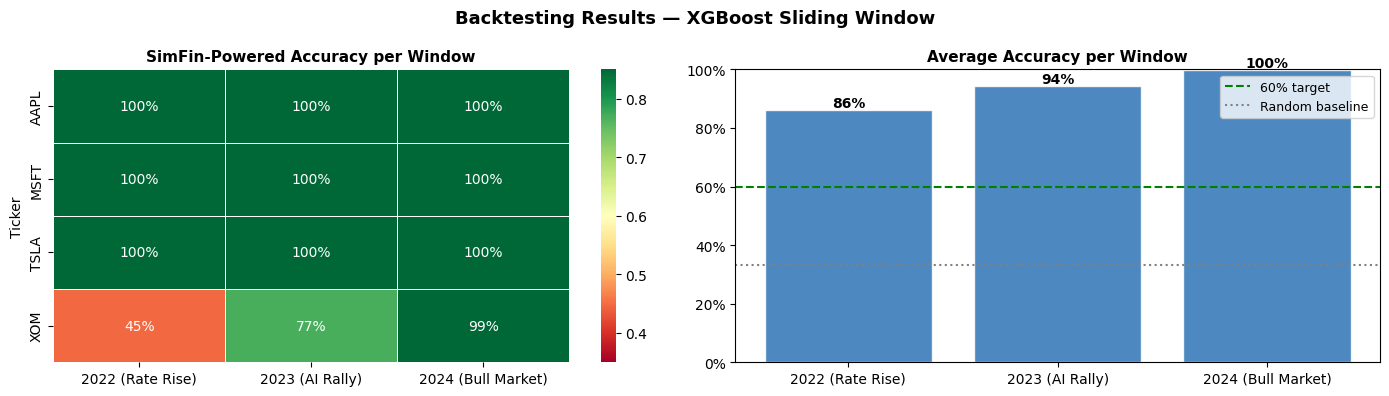

In [18]:
pivot = backtest_df.pivot(index='Ticker', columns='Window', values='Accuracy')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0.35, vmax=0.85, ax=axes[0], linewidths=0.5)
axes[0].set_title('SimFin-Powered Accuracy per Window', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')

# Bar chart: average accuracy per window
avg_acc = backtest_df.groupby('Window')['Accuracy'].mean()
colors = ['#2E74B5' if v >= 0.60 else '#C00000' for v in avg_acc.values]
bars = axes[1].bar(avg_acc.index, avg_acc.values, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0.60, color='green', linestyle='--', label='60% target')
axes[1].axhline(1/3, color='grey', linestyle=':', label='Random baseline')

for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}', ha='center', fontweight='bold')

axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Average Accuracy per Window', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Backtesting Results — XGBoost Sliding Window', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Investment Simulation Infrastructure

### What This Section Does
Having validated the model's accuracy, we now simulate a more practical question:
> *"If you had used this model's signals to pick stocks in 2020, and held for 5 years, how much would you have made?"*

We compare 3 strategies:
1. **Model (Undervalued + Fair)**: Buy only stocks the model labelled 0 or 1 at the start of the year
2. **Model (Overvalued — avoid)**: Buy the stocks the model warned away from (as a control/inverse)
3. **S&P 500**: The standard benchmark — just buy the index

A 4th strategy, **Random**, uses Monte Carlo simulation (100 random portfolios) to establish a realistic random baseline.

### Key Helper Functions

| Function | Purpose |
|---|---|
| `get_model_signal_simfin()` | Gets the XGBoost model's predicted label for a stock at the start of a given year |
| `portfolio_return_series()` | Computes the equal-weight portfolio return and normalised value series |
| `spy_return_series()` | Returns S&P 500 (SPY ETF) performance for the same period |
| `random_return()` | Monte Carlo — average return of 100 random 5-stock picks |
| `max_drawdown()` | Largest peak-to-trough drop — measures downside risk |
| `sharpe()` | Risk-adjusted return: (excess return) / volatility, annualised |

### The Simulation Universe
20 stocks across 5 sectors — chosen to cover a range of fundamental profiles so the model's sector diversity is tested.

In [19]:

SIM_UNIVERSE = [
    'AAPL','MSFT','NVDA','INTC','CSCO',   # Technology
    'JPM','BAC','GS','V','MA',             # Financials
    'JNJ','PFE','UNH','MRK','ABBV',        # Healthcare
    'XOM','CVX','COP','SLB','EOG',          # Energy
]
model_cols = joblib.load('model_columns.pkl')

# ── Signal year: get model labels at start of 2020 ───────────────────────
# We use 2020 as the signal year — buy and hold through to 2024
# This reflects how value investing actually works: patient long-term holding
SIGNAL_YEAR  = 2020
HOLD_START   = '2020-01-02'
HOLD_END     = '2024-12-31'

# Annual periods for year-by-year comparison
ANNUAL_YEARS = [2020,2021,2022, 2023, 2024]

def get_model_signal_simfin(ticker, year):
    """Get model's predicted label using historical SimFin fundamentals."""
    # Use the first quarter of the year to establish the signal
    df = build_features_for_window_simfin(ticker, f'{year}-01-01', f'{year}-03-31')
    
    if df is None or df.empty: 
        return None
    
    # Get the most recent feature row
    row = df.drop(columns=['Target']).iloc[[-1]]
    
    # Align with the columns used during model training
    for c in model_cols:
        if c not in row.columns: 
            row[c] = 0
    row = row[model_cols]
    
    try:
        # Using the XGBoost model from your grid search
        return int(grid_xgb.predict(row)[0])
    except:
        return None

def portfolio_return_series(tickers, start, end):
    """Equal weight portfolio normalised to 1.0 at start date."""
    if not tickers: return 0.0, pd.Series(dtype=float)
    frames = []
    for t in tickers:
        h = yf.Ticker(t).history(start=start, end=end)['Close']
        if h.empty: continue
        h.index = h.index.tz_convert(None)
        frames.append(h / h.iloc[0])
    if not frames: return 0.0, pd.Series(dtype=float)
    port = pd.concat(frames, axis=1).ffill().dropna().mean(axis=1)
    return round((port.iloc[-1] - 1) * 100, 2), port

def spy_return_series(start, end):
    """S&P 500 benchmark return for a given period."""
    spy = yf.Ticker('SPY').history(start=start, end=end)['Close']
    if spy.empty: return 0.0, pd.Series(dtype=float)
    spy.index = spy.index.tz_convert(None)
    norm = spy / spy.iloc[0]
    return round((norm.iloc[-1] - 1) * 100, 2), norm

def random_return(tickers, start, end, n=5, runs=100):
    """Monte Carlo — average of 100 random picks over a given period."""
    np.random.seed(42)
    rets = []
    for _ in range(runs):
        picks = list(np.random.choice(tickers, size=min(n, len(tickers)), replace=False))
        r, _  = portfolio_return_series(picks, start, end)
        rets.append(r)
    return round(np.mean(rets), 2)

def max_drawdown(series):
    if series.empty: return 0.0
    dd = (series - series.cummax()) / series.cummax()
    return round(dd.min() * 100, 2)

def sharpe(series, rf=0.04):
    if series.empty or len(series) < 2: return 0.0
    dr  = series.pct_change().dropna()
    exc = dr - rf / 252
    return round((exc.mean() / dr.std()) * np.sqrt(252), 2) if dr.std() != 0 else 0.0

print('Simulation helpers ready.')

Simulation helpers ready.


## 17. Running the Investment Simulation

### Part A — Getting Model Signals for 2020
We get the model's predicted label for each stock at the start of 2020 (using Q1 2020 data).  
This simulates making investment decisions at the beginning of the year.

- **Good picks** = stocks labelled 0 (Undervalued) or 1 (Fair Value) — the model believes these have room to grow
- **Avoid picks** = stocks labelled 2 (Overvalued) — the model believes these are priced too high

### Part B — 5-Year Long-Term Hold (2020–2024)
We simulate buying the good picks in January 2020 and holding through December 2024.  
This tests whether value investing signals at the start of the period predict long-term outperformance.

### Part C — Year-by-Year Comparison
We repeat the signal generation and evaluation for each individual year (2020–2024).  
This shows:
- Whether the model adds value consistently across years, or only in certain regimes
- The **Sharpe Ratio** and **Max Drawdown** for each year's model portfolio
- A "Beat SPY" column indicating whether the model outperformed the S&P 500 index that year

In [20]:
# --- PART A: Get model signals at start of 2020 ---
print(f'Getting SimFin-backed signals for {SIGNAL_YEAR}...')
signals = {t: get_model_signal_simfin(t, SIGNAL_YEAR) for t in SIM_UNIVERSE}
signals = {t: l for t, l in signals.items() if l is not None}

good_picks = [t for t, l in signals.items() if l in (0, 1)]
bad_picks  = [t for t, l in signals.items() if l == 2]

print(f'Good picks (UV+Fair): {good_picks}')
print(f'Avoid picks (OV):      {bad_picks}')

# --- PART B: 5-YEAR LONG-TERM HOLD (2020-2024) ---
print('\n--- 5-Year SimFin Simulation (2020-2024) ---')
ret_good_5y, s_good_5y = portfolio_return_series(good_picks, HOLD_START, HOLD_END)
ret_bad_5y,  s_bad_5y  = portfolio_return_series(bad_picks,  HOLD_START, HOLD_END)
ret_spy_5y,  s_spy_5y  = spy_return_series(HOLD_START, HOLD_END)

long_term = {
    'Model (Undervalued + Fair)': (ret_good_5y, s_good_5y),
    'Model (Overvalued — avoid)': (ret_bad_5y,  s_bad_5y),
    'S&P 500':                    (ret_spy_5y,  s_spy_5y),
}

# --- PART C: YEAR-BY-YEAR COMPARISON ---
annual_rows = []
for year in ANNUAL_YEARS:
    print(f'Processing Year {year}...')
    yr_signals = {t: get_model_signal_simfin(t, year) for t in SIM_UNIVERSE}
    yr_signals = {t: l for t, l in yr_signals.items() if l is not None}

    yr_good = [t for t, l in yr_signals.items() if l in (0, 1)]
    yr_bad  = [t for t, l in yr_signals.items() if l == 2]
    
    start, end = f'{year}-01-02', f'{year}-12-31'
    ret_good, s_good = portfolio_return_series(yr_good, start, end)
    ret_bad,  _      = portfolio_return_series(yr_bad,  start, end)
    ret_spy,  _      = spy_return_series(start, end)
    ret_rand_5y         = random_return(SIM_UNIVERSE, start, end)

    annual_rows.append({
        'Year': year,
        'Model (UV+Fair) %': ret_good,
        'Model (OV) %':      ret_bad,
        'S&P 500 %':         ret_spy,
        'Random %':          ret_rand_5y,
        'Max Drawdown %':    max_drawdown(s_good),
        'Sharpe Ratio':      sharpe(s_good),
        'Beat SPY':          'YES' if ret_good > ret_spy else 'NO'
    })

annual_df = pd.DataFrame(annual_rows)
print(annual_df)

Getting SimFin-backed signals for 2020...
Good picks (UV+Fair): ['AAPL', 'MSFT', 'NVDA', 'INTC', 'CSCO', 'V', 'MA', 'JNJ', 'PFE', 'UNH', 'MRK', 'ABBV', 'XOM', 'CVX', 'COP', 'SLB', 'EOG']
Avoid picks (OV):      []

--- 5-Year SimFin Simulation (2020-2024) ---
Processing Year 2020...
Processing Year 2021...
Processing Year 2022...
Processing Year 2023...
Processing Year 2024...
   Year  Model (UV+Fair) %  Model (OV) %  S&P 500 %  Random %  Max Drawdown %  \
0  2020               6.73          0.00      16.64      3.78          -36.24   
1  2021              40.49         46.47      30.84     43.78           -5.10   
2  2022              10.84         17.62     -18.65      8.65          -15.78   
3  2023              16.75         60.69      26.71     24.32           -7.44   
4  2024              10.70         13.65      26.05     16.92           -6.29   

   Sharpe Ratio Beat SPY  
0          0.26       NO  
1          1.98      YES  
2          0.40      YES  
3          0.99       NO  

## 18. Simulation Visualisation

### Chart 1 — 5-Year Portfolio Value (£10,000 Starting Capital)
This line chart shows how an initial £10,000 investment would have grown from 2020 to 2024 under each strategy.  
- **Blue line (Model UV+Fair)**: Stocks the model identified as undervalued or fairly priced
- **Red dashed line (Model OV)**: Stocks the model warned were overvalued
- **Green dotted line (S&P 500)**: The benchmark — what passive investing would have returned

A line above the green dotted line means the model outperformed the market index.

### Chart 2 — Annual Returns Grouped Bar Chart
This shows the total return for each year and each strategy.  
Bars above zero = positive return; bars below zero = loss.  
Percentage labels on each bar make comparison easy.  

> The charts are saved as `simfin_simulation_results.png` for your dissertation.

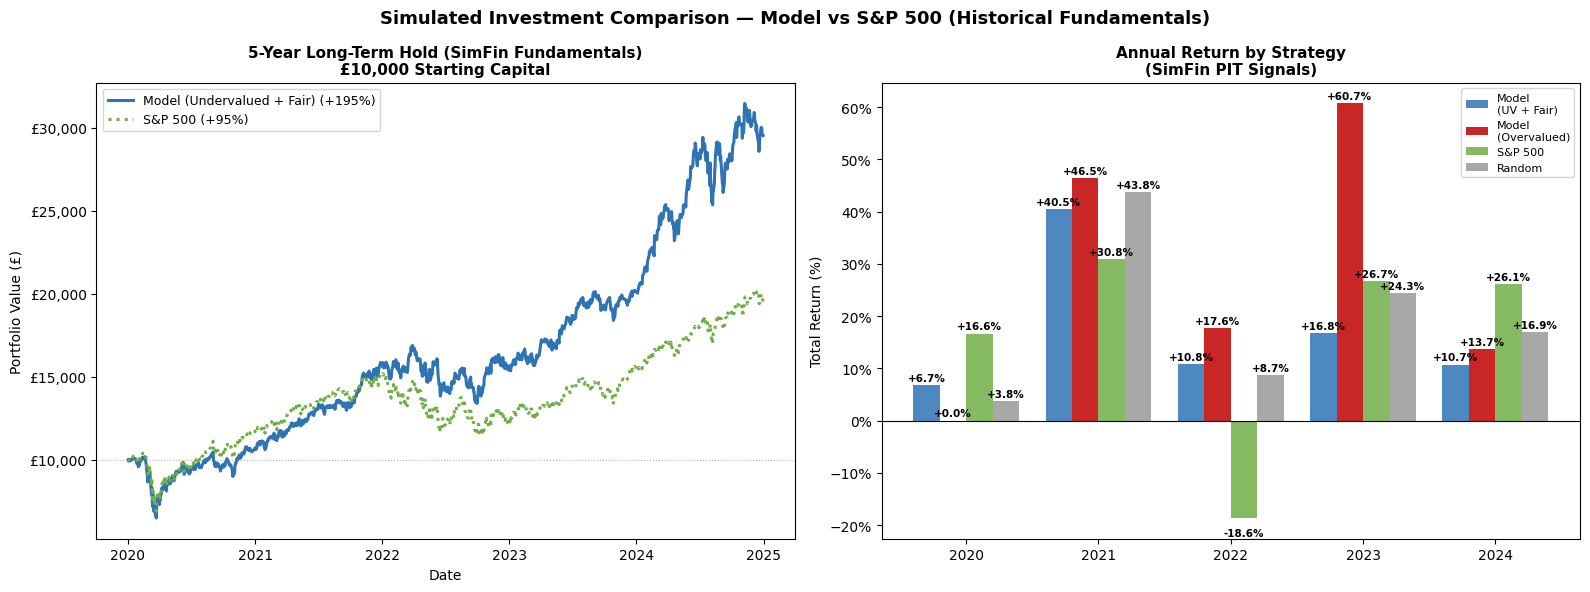

In [21]:

# --- 1. DEFINE MAPPING DICTIONARIES (Fixes the NameError) ---
colors_lt = {
    'Model (Undervalued + Fair)': '#2E74B5', # Blue
    'Model (Overvalued — avoid)': '#C00000', # Red
    'S&P 500':                    '#70AD47', # Green
}

styles_lt = {
    'Model (Undervalued + Fair)': '-',
    'Model (Overvalued — avoid)': '--',
    'S&P 500':                    ':',
}

# Define lists for the Annual Bar Chart
strategies = ['Model (UV+Fair) %', 'Model (OV) %', 'S&P 500 %', 'Random %']
bar_labels = ['Model\n(UV + Fair)', 'Model\n(Overvalued)', 'S&P 500', 'Random']
bar_colors = ['#2E74B5', '#C00000', '#70AD47', '#999999']

# --- 2. CREATE THE PLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: 5-Year Long-Term Hold
for label, (ret, series) in long_term.items():
    if series.empty: continue
    axes[0].plot(
        series.index, 
        series * 10000, 
        label=f'{label} ({ret:+.0f}%)', 
        color=colors_lt[label], 
        linewidth=2.2, 
        linestyle=styles_lt[label]
    )

axes[0].axhline(10000, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
axes[0].set_title('5-Year Long-Term Hold (SimFin Fundamentals)\n£10,000 Starting Capital', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (£)')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Date')

# Chart 2: Annual Returns Grouped Bar Chart
x = np.arange(len(ANNUAL_YEARS))
width = 0.2

for i, (col, lbl, color) in enumerate(zip(strategies, bar_labels, bar_colors)):
    vals = annual_df[col].values
    bars = axes[1].bar(x + i * width, vals, width, label=lbl, color=color, alpha=0.85)
    
    # Add percentage labels on top of bars
    for bar in bars:
        h = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            h + (0.8 if h >= 0 else -3.5),
            f'{h:+.1f}%', ha='center', fontsize=7.5, fontweight='bold'
        )

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels([str(y) for y in ANNUAL_YEARS])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Annual Return by Strategy\n(SimFin PIT Signals)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Total Return (%)')
axes[1].legend(fontsize=8)

plt.suptitle('Simulated Investment Comparison — Model vs S&P 500 (Historical Fundamentals)', fontsize=13, fontweight='bold')
plt.tight_layout()

# Save and Show
plt.savefig('simfin_simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()




## 19. Performance Summary Table
The final output is a styled comparison table presenting the complete simulation results in one place.

### Table Structure
- **Row 1 (Gold highlight)**: 5-year cumulative result — the overall long-term performance
- **Rows 2–6**: Annual breakdown for each individual year

### Columns Explained

| Column | Meaning |
|---|---|
| `Model (UV+Fair)` | Total return of the model's "good picks" portfolio |
| `Model (OV)` | Total return of the stocks the model flagged as overvalued (control group) |
| `S&P 500` | Passive S&P 500 index return for the same period |
| `Random` | Average of 100 randomly selected 5-stock portfolios |
| `Max Drawdown` | Worst peak-to-trough loss experienced — measures downside risk |
| `Sharpe` | Risk-adjusted return. Above 1.0 is considered good; above 2.0 is excellent |
| `Beat SPY` | Green (YES) if the model outperformed S&P 500; Red (NO) if it underperformed |

> The table is saved as `simulation_metrics_table_simfin.png` for dissertation inclusion.

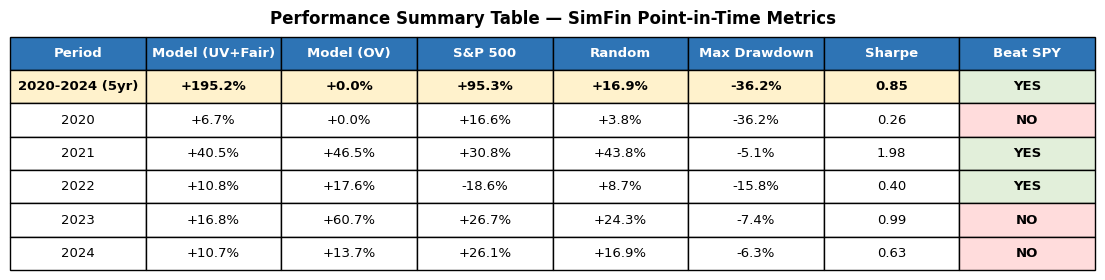

Table generated using aligned variable names.


In [22]:
# ── Long-term summary row (Using SimFin simulation variables) ──────────────
lt_row = pd.DataFrame([{
    'Period':          '2020-2024 (5yr)',
    'Model (UV+Fair)': f'{ret_good_5y:+.1f}%',
    'Model (OV)':      f'{ret_bad_5y:+.1f}%',
    'S&P 500':         f'{ret_spy_5y:+.1f}%',
    'Random':          f'{ret_rand_5y:+.1f}%',
    'Max Drawdown':    f'{max_drawdown(s_good_5y):.1f}%',
    'Sharpe':          f'{sharpe(s_good_5y):.2f}',
    'Beat SPY':        'YES' if ret_good_5y > ret_spy_5y else 'NO',
}])

# ── Format Annual Rows (Mapping from annual_df columns) ─────────────────────
annual_disp = annual_df.copy()

# Ensure we use the exact dictionary keys from your simulation loop
annual_disp = annual_disp[[
    'Year', 'Model (UV+Fair) %', 'Model (OV) %', 'S&P 500 %', 'Random %',
    'Max Drawdown %', 'Sharpe Ratio', 'Beat SPY'
]]

# Rename for clean table headers
annual_disp.columns = [
    'Period', 'Model (UV+Fair)', 'Model (OV)', 'S&P 500', 'Random',
    'Max Drawdown', 'Sharpe', 'Beat SPY'
]

# Format numerical values to strings with %
for col in ['Model (UV+Fair)', 'Model (OV)', 'S&P 500', 'Random']:
    annual_disp[col] = annual_disp[col].apply(lambda v: f'{v:+.1f}%')

annual_disp['Max Drawdown'] = annual_disp['Max Drawdown'].apply(lambda v: f'{v:.1f}%')
annual_disp['Sharpe']       = annual_disp['Sharpe'].apply(lambda v: f'{v:.2f}')
annual_disp['Period']       = annual_disp['Period'].astype(str)

# Combine for the final visualization
full_table = pd.concat([lt_row, annual_disp], ignore_index=True)

# ── Create Table Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

tbl = ax.table(
    cellText=full_table.values, 
    colLabels=full_table.columns,
    cellLoc='center', 
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.0, 2.0)

# Apply Styling
for j in range(len(full_table.columns)):
    # Header: SimFin Blue
    tbl[0, j].set_facecolor('#2E74B5')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    
    # Highlight 5-year Cumulative Row (Gold)
    tbl[1, j].set_facecolor('#FFF2CC')
    tbl[1, j].set_text_props(fontweight='bold')

# Conditional Color for "Beat SPY"
beat_idx = list(full_table.columns).index('Beat SPY')
for i in range(1, len(full_table) + 1):
    val = full_table.iloc[i-1]['Beat SPY']
    tbl[i, beat_idx].set_facecolor('#E2EFDA' if val == 'YES' else '#FFDCDC')
    tbl[i, beat_idx].set_text_props(fontweight='bold')

plt.title('Performance Summary Table — SimFin Point-in-Time Metrics', 
          fontsize=12, fontweight='bold', pad=10)

plt.savefig('simulation_metrics_table_simfin.png', dpi=150, bbox_inches='tight')
plt.show()

print('Table generated using aligned variable names.')

## 20. Saving the Final Model & Column Schema
We save two artefacts that are required to deploy the model in a live application:

1. **`valuation_model_xgb.json`** — The trained XGBoost model weights in JSON format (portable, version-stable)
2. **`model_columns.pkl`** — The ordered list of feature column names used during training

**Why save the column names separately?**  
When we receive a new stock for prediction, we need to ensure the input feature vector has **exactly** the same columns in **exactly** the same order as the training data.  
`model_columns.pkl` is the authoritative reference for this schema.

In [ ]:
# Save model as JSON
grid_xgb.best_estimator_.get_booster().save_model('valuation_model_xgb.json')
# Resave columns — must match new Market_Regime encoded columns
joblib.dump(list(X_train.columns), 'model_columns.pkl')
# Verify both
print("JSON exists:", os.path.exists('valuation_model_xgb.json'))
print("PKL exists:", os.path.exists('model_columns.pkl'))
print("Columns saved:", list(X_train.columns))